# Compare FFT before/after 60/100 Hz notch removal

Loads the same sample(s) from the original dataset (`SRC_DIR`) and the new denotched copy
(`DST_DIR`, built by `build_denotched_dataset.py`), and plots magnitude spectra before/after
the notch, both unnormalized and normalized (`normalize_fft` from `post_process.py`).

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from io_utils import load
from post_process import extract_signal, normalize_fft
from denotch import interpolate_notch

# **** point these at your actual dataset ****
SRC_DIR = Path("../data/samples")  # original
DST_DIR = Path("../data-denotched/samples")  # produced by build_denotched_dataset.py
SAMPLE_IDS = None  # e.g. ["000000", "000001"]; None = first 3 found under SRC_DIR

SPIKE_FREQS = [60.0, 100.0]
NOTCH_HALF_WIDTH_HZ = 1.0
SIGNAL_MODE = "magnitude"
NORMALIZE_MODE = "z-sample"

sample_ids = SAMPLE_IDS or sorted(p.name for p in SRC_DIR.glob("*") if p.is_dir())[:3]
print(f"Comparing {len(sample_ids)} samples: {sample_ids}")

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Comparing 3 samples: ['000000', '000001', '000002']


In [ ]:
def load_sample_fft(sample_id: str):
    """Load raw complex fft + freqs from the ORIGINAL dataset (source of truth, always pre-denotch)."""
    npz = load(SRC_DIR / sample_id / "inputs/03_fft_shifts.npz")
    return npz["fft"], npz["freqs"]


def mean_magnitude(fft: np.ndarray) -> np.ndarray:
    """(B,L,F,2) complex -> (F,) magnitude averaged over batch, lasers, x/y."""
    mag = extract_signal(fft, "magnitude")  # (B,L,F,2)
    return mag.mean(axis=(0, 1, 3))


samples = {}
for sid in sample_ids:
    fft_before, freqs = load_sample_fft(sid)
    fft_after = interpolate_notch(fft_before, freqs, spike_freqs=SPIKE_FREQS, half_width_hz=NOTCH_HALF_WIDTH_HZ)

    mag_before_raw = extract_signal(fft_before, SIGNAL_MODE).astype(np.float32)
    mag_after_raw = extract_signal(fft_after, SIGNAL_MODE).astype(np.float32)

    mag_before_norm = normalize_fft(mag_before_raw, NORMALIZE_MODE)
    mag_after_norm = normalize_fft(mag_after_raw, NORMALIZE_MODE)

    samples[sid] = dict(
        freqs=freqs,
        before_unnorm=mean_magnitude(fft_before),
        after_unnorm=mean_magnitude(fft_after),
        before_norm=mag_before_norm.mean(axis=(0, 1, 3)),
        after_norm=mag_after_norm.mean(axis=(0, 1, 3)),
    )
print("Loaded + denotched:", list(samples.keys()))

Loaded + denotched: ['000000', '000001', '000002']


## Full spectrum: unnormalized (top) vs normalized (bottom), before vs after

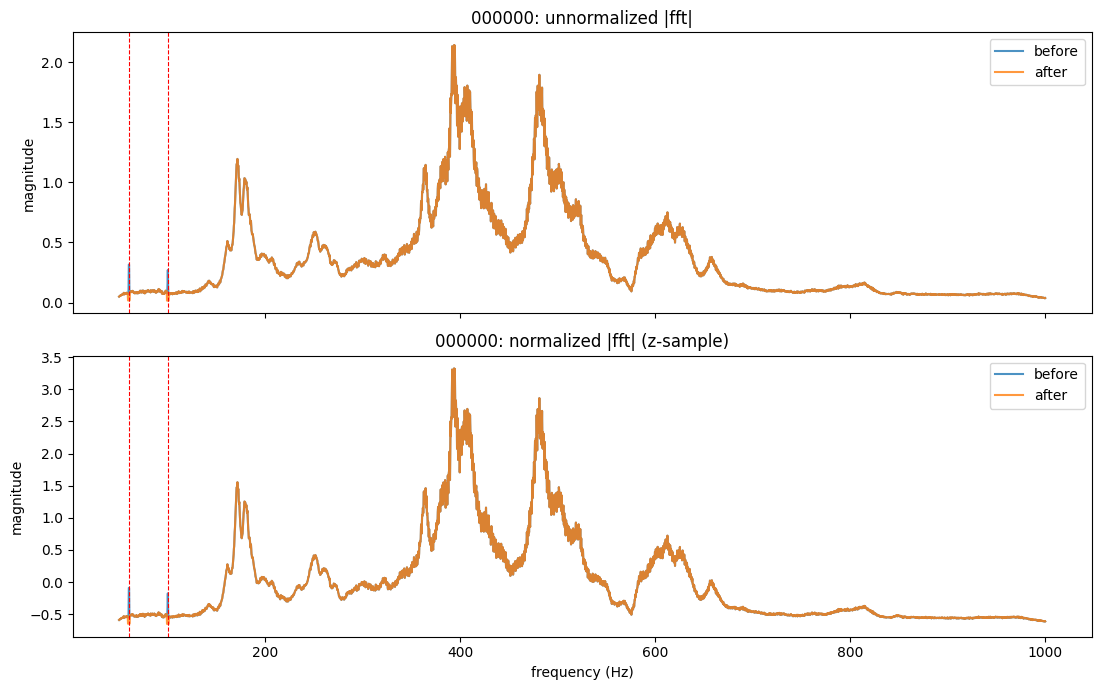

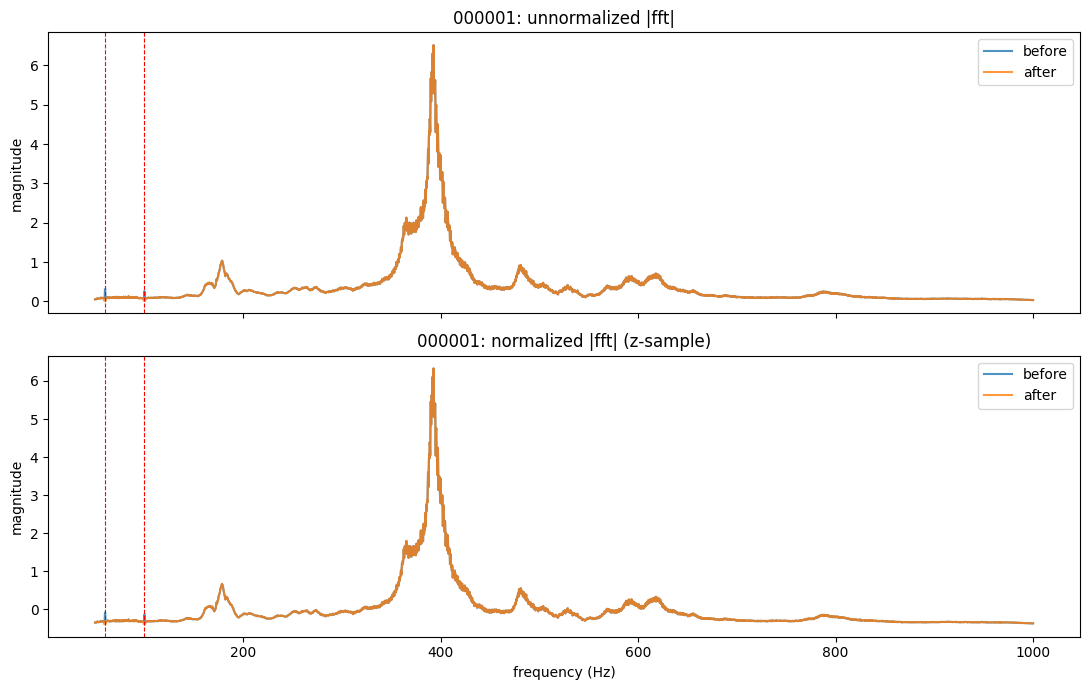

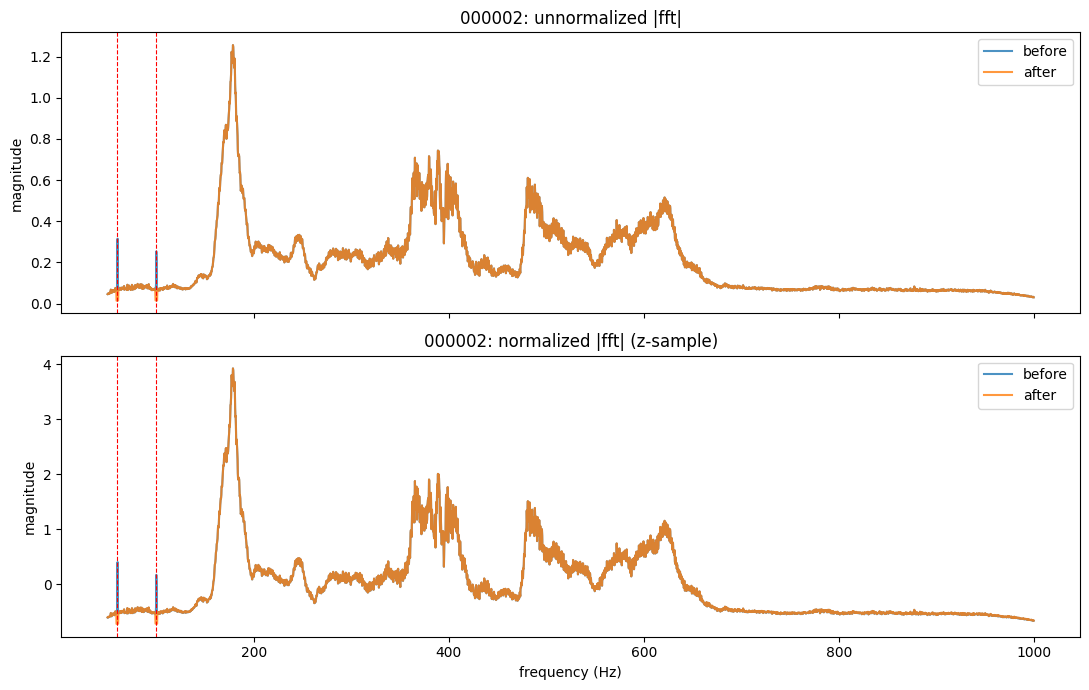

In [ ]:
for sid, d in samples.items():
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for ax, (before, after), title in [
        (axes[0], (d["before_unnorm"], d["after_unnorm"]), "unnormalized |fft|"),
        (axes[1], (d["before_norm"], d["after_norm"]), f"normalized |fft| ({NORMALIZE_MODE})"),
    ]:
        ax.plot(d["freqs"], before, label="before", alpha=0.8)
        ax.plot(d["freqs"], after, label="after", alpha=0.8)
        for f in SPIKE_FREQS: ax.axvline(f, color="red", linestyle="--", linewidth=0.8)
        ax.set(title=f"{sid}: {title}", ylabel="magnitude")
        ax.legend()
    axes[-1].set_xlabel("frequency (Hz)")
    fig.tight_layout()
    plt.show()

## Zoomed-in view around each spike (shows the interpolation directly)

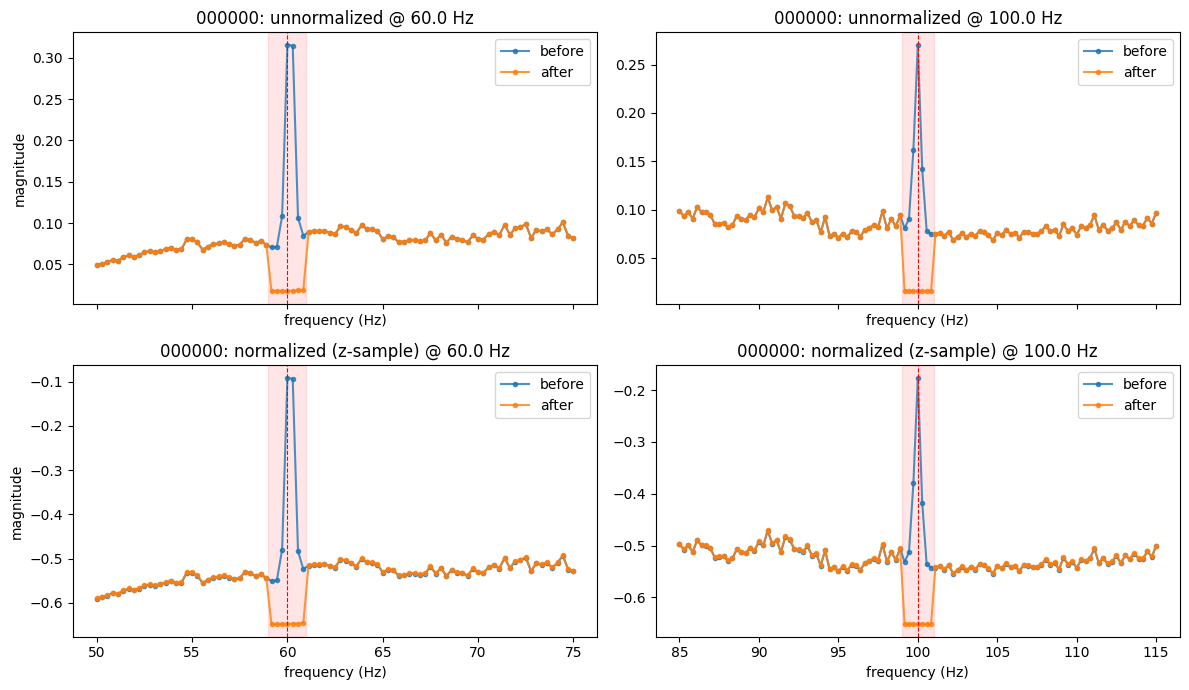

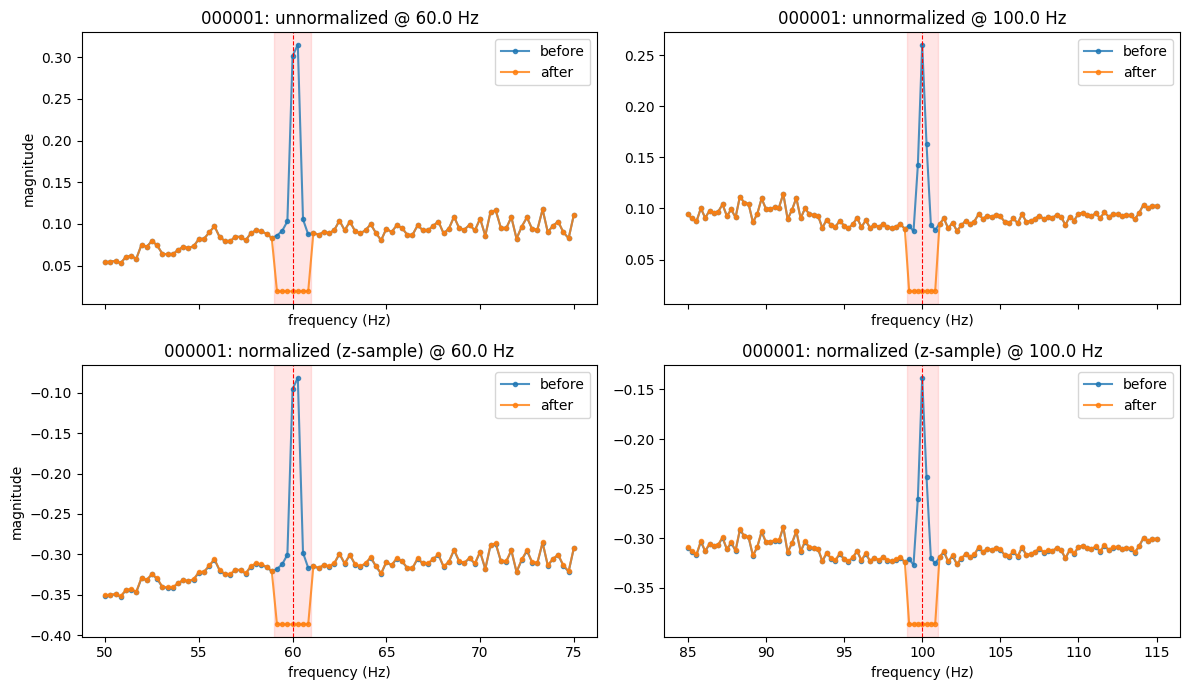

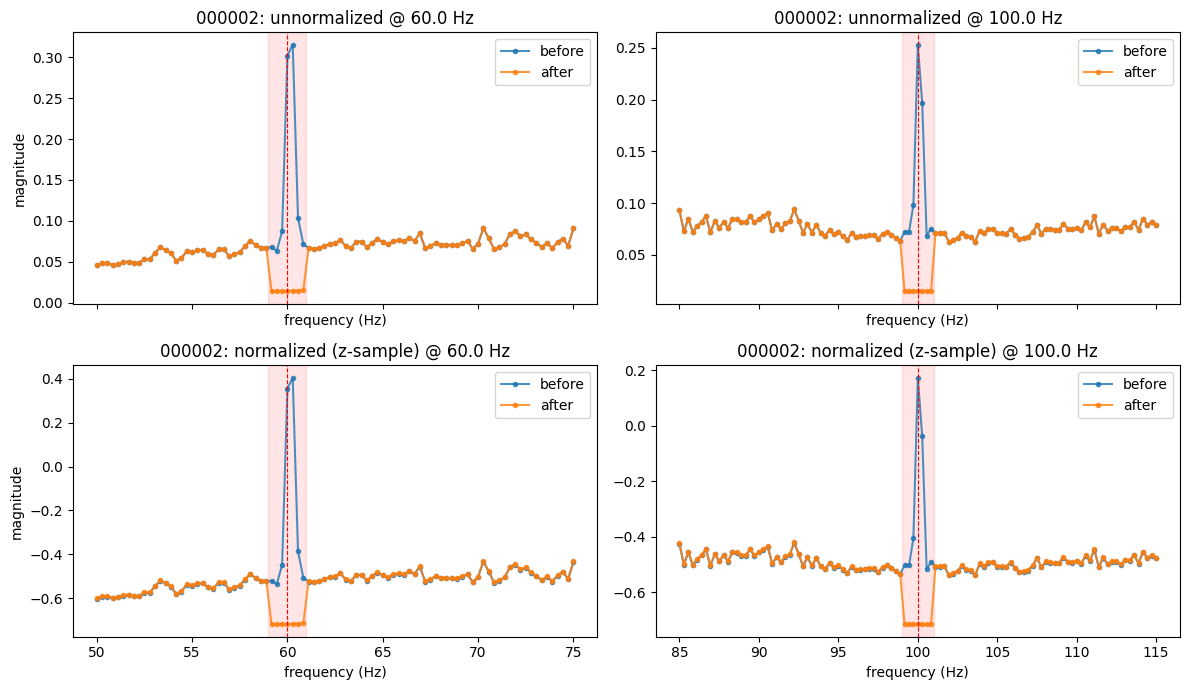

In [ ]:
ZOOM_HALF_WINDOW_HZ = 15.0  # window shown on each side of a spike

for sid, d in samples.items():
    fig, axes = plt.subplots(2, len(SPIKE_FREQS), figsize=(6 * len(SPIKE_FREQS), 7), sharex="col")
    freqs = d["freqs"]
    for col, spike_f in enumerate(SPIKE_FREQS):
        zoom = (freqs >= spike_f - ZOOM_HALF_WINDOW_HZ) & (freqs <= spike_f + ZOOM_HALF_WINDOW_HZ)
        for row, (before, after), title in [
            (0, (d["before_unnorm"], d["after_unnorm"]), "unnormalized"),
            (1, (d["before_norm"], d["after_norm"]), f"normalized ({NORMALIZE_MODE})"),
        ]:
            ax = axes[row, col]
            ax.plot(freqs[zoom], before[zoom], "o-", label="before", alpha=0.8, markersize=3)
            ax.plot(freqs[zoom], after[zoom], "o-", label="after", alpha=0.8, markersize=3)
            ax.axvspan(spike_f - NOTCH_HALF_WIDTH_HZ, spike_f + NOTCH_HALF_WIDTH_HZ, color="red", alpha=0.1)
            ax.axvline(spike_f, color="red", linestyle="--", linewidth=0.8)
            ax.set(title=f"{sid}: {title} @ {spike_f} Hz", xlabel="frequency (Hz)")
            if col == 0: ax.set_ylabel("magnitude")
            ax.legend()
    fig.tight_layout()
    plt.show()